# Лабораторная работа: обработка временного ряда NMDB

**Станция:** Тикси (TXBY)  
**Период:** 20–29 сентября 2015 года  
**Разрешение:** 1 минута, UTC  

Источник данных: [NMDB NEST](https://www.nmdb.eu/nest/). Данные загружаются непосредственно из ASCII-ответа NEST.

In [1]:
from io import StringIO
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
url = r'''https://www.nmdb.eu/nest/draw_graph.php?formchk=1&stations[]=TXBY&tabchoice=revori&dtype=corr_for_efficiency&tresolution=0&yunits=0&date_choice=bydate&start_day=20&start_month=9&start_year=2015&start_hour=0&start_min=0&end_day=29&end_month=9&end_year=2015&end_hour=23&end_min=59&output=ascii'''
response = requests.get(url, timeout=60)
response.raise_for_status()

data_lines = [line.strip() for line in response.text.splitlines() if line[:4].isdigit() and ';' in line]
df = pd.read_csv(StringIO('\n'.join(data_lines)), sep=';', names=['datetime', 'corr_for_efficiency'])
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df['corr_for_efficiency'] = pd.to_numeric(df['corr_for_efficiency'], errors='coerce')
df = df.dropna().sort_values('datetime').reset_index(drop=True)
print(f'Загружено строк из NMDB: {len(df)}')


Загружено строк из NMDB: 14032


In [2]:
df.head(10)

,datetime,corr_for_efficiency
0,2015-09-20 00:00:00+00:00,90.800
1,2015-09-20 00:01:00+00:00,96.267
2,2015-09-20 00:02:00+00:00,92.800
3,2015-09-20 00:03:00+00:00,93.867
4,2015-09-20 00:04:00+00:00,92.933
5,2015-09-20 00:05:00+00:00,94.400
6,2015-09-20 00:06:00+00:00,95.333
7,2015-09-20 00:07:00+00:00,92.933
8,2015-09-20 00:08:00+00:00,94.667
9,2015-09-20 00:09:00+00:00,92.800


In [3]:
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df['corr_for_efficiency'] = pd.to_numeric(df['corr_for_efficiency'], errors='coerce')
df = df.dropna().sort_values('datetime').drop_duplicates('datetime').reset_index(drop=True)

start = pd.Timestamp('2015-09-20 00:00:00', tz='UTC')
end = pd.Timestamp('2015-09-29 23:59:00', tz='UTC')
full_index = pd.date_range(start, end, freq='min')
series = df.set_index('datetime')['corr_for_efficiency'].reindex(full_index)
series.index.name = 'datetime'
print(f'Ожидаемых минут: {len(full_index)}')
print(f'Полученных наблюдений: {series.notna().sum()}')
print(f'Пропусков: {series.isna().sum()}')


Ожидаемых минут: 14400
Полученных наблюдений: 14032
Пропусков: 368


## Обнаружение выбросов

Критерий трёх стандартных отклонений: `abs(x - mean) > 3 * std`.

In [4]:
available = series.dropna()
mu = available.mean()
sigma = available.std(ddof=0) # смещенная оценка
lower_bound = mu - 3 * sigma
upper_bound = mu + 3 * sigma
outlier_mask = series.notna() & ((series < lower_bound) | (series > upper_bound))
print(f"Среднее: {mu:.6f}")
print(f"Стандартное отклонение: {sigma:.6f}")
print(f"Границы 3σ: [{lower_bound:.6f}; {upper_bound:.6f}]")
print(f"Выбросов: {outlier_mask.sum()}")


Среднее: 85.835529
Стандартное отклонение: 282.212271
Границы 3σ: [-760.801283; 932.472342]
Выбросов: 14


## Медиана и замена

Медиана рассчитывается только по корректным наблюдениям.

In [5]:
missing_mask = series.isna()
median_value = available[~outlier_mask].median()
cleaned = series.mask(missing_mask | outlier_mask, median_value)
print(f"Медиана без пропусков и выбросов: {median_value:.3f}")
print(f"Заменено пропусков: {missing_mask.sum()}")
print(f"Заменено выбросов: {outlier_mask.sum()}")
print(f"Всего замен: {(missing_mask | outlier_mask).sum()}")
print(f"Пропусков после обработки: {cleaned.isna().sum()}")


Медиана без пропусков и выбросов: 86.133
Заменено пропусков: 368
Заменено выбросов: 14
Всего замен: 382
Пропусков после обработки: 0


## Исходный и очищенный временные ряды

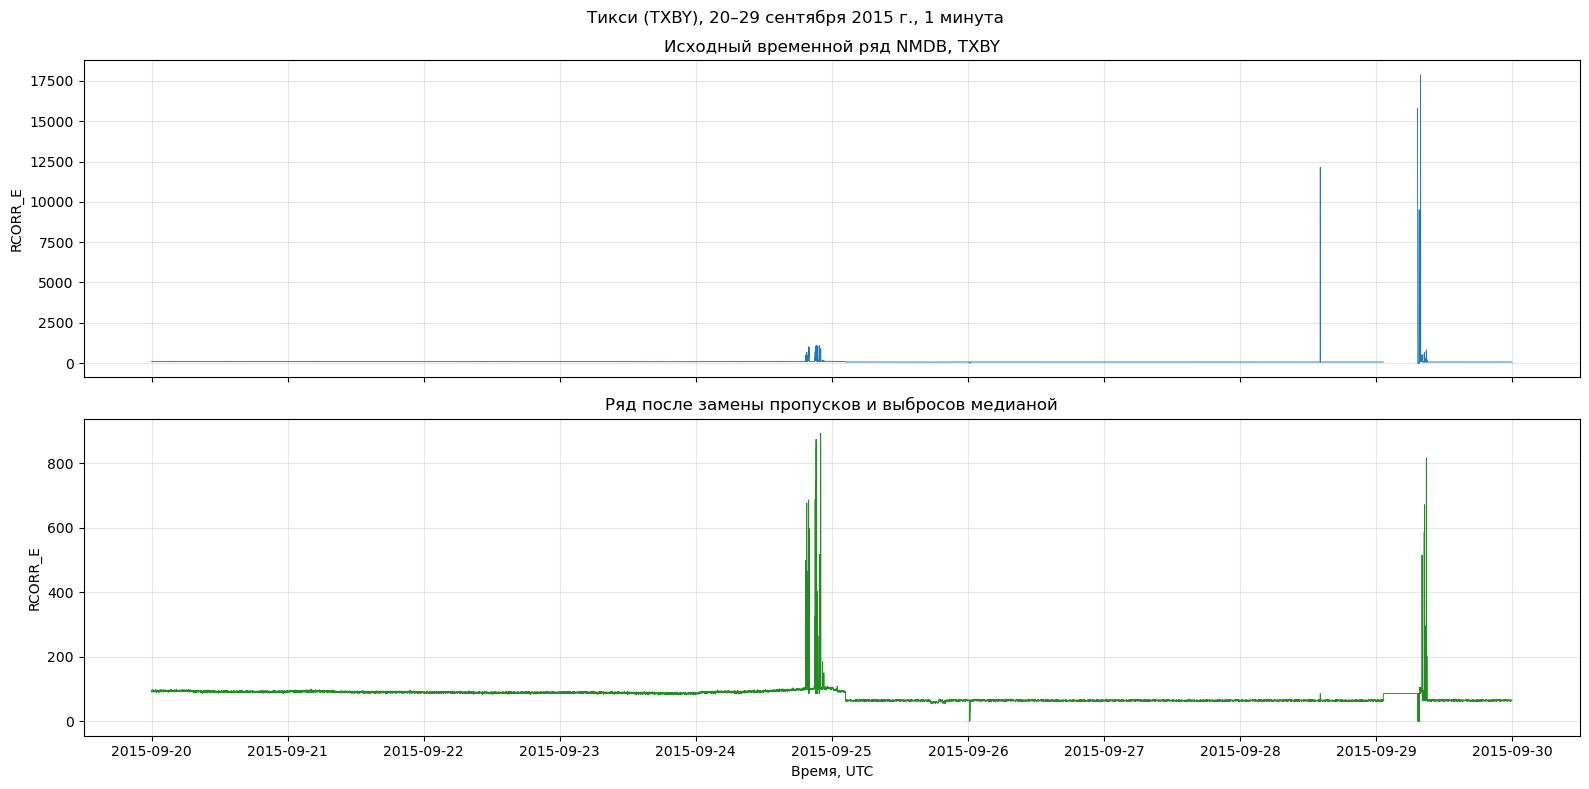

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(series.index, series, linewidth=0.65)
axes[0].set_title("Исходный временной ряд NMDB, TXBY")
axes[0].set_ylabel("RCORR_E")
axes[0].grid(True, alpha=0.3)
axes[1].plot(cleaned.index, cleaned, linewidth=0.65, color="forestgreen")
axes[1].set_title("Ряд после замены пропусков и выбросов медианой")
axes[1].set_ylabel("RCORR_E")
axes[1].set_xlabel("Время, UTC")
axes[1].grid(True, alpha=0.3)
fig.suptitle("Тикси (TXBY), 20–29 сентября 2015 г., 1 минута")
fig.tight_layout()
plt.show()


## Итоговые результаты

In [7]:
total_count = len(full_index)
observed_count = int(series.notna().sum())
missing_count = int(missing_mask.sum())
outlier_count = int(outlier_mask.sum())
replaced_count = int((missing_mask | outlier_mask).sum())
summary = pd.DataFrame({
    'Показатель': ['Полный ряд', 'Полученные наблюдения', 'Пропуски', 'Выбросы', 'Всего замен', 'Медиана'],
    'Количество / значение': [total_count, observed_count, missing_count, outlier_count, replaced_count, median_value],
    'Доля от полного ряда, %': [100.0, observed_count / total_count * 100, missing_count / total_count * 100, outlier_count / total_count * 100, replaced_count / total_count * 100, np.nan]
})
summary.style.format({'Количество / значение': '{:.3f}', 'Доля от полного ряда, %': '{:.3f}'})
display(summary)


,Показатель,Количество / значение,"Доля от полного ряда, %"
0,Полный ряд,14400.000,100.000000
1,Полученные наблюдения,14032.000,97.444444
2,Пропуски,368.000,2.555556
3,Выбросы,14.000,0.097222
4,Всего замен,382.000,2.652778
5,Медиана,86.133,NaN
